# Multi-Model Trust Evaluation — Adult Census Income

Extends the single-model evaluation pipeline to **train and compare four classifiers**
on the same task, and evaluate them side by side on performance, explainability,
fairness, and robustness — ending in one comparative HTML report plus a final
recommendation section.

**Models compared:**
- Logistic Regression (linear baseline, fully transparent)
- Decision Tree (single tree, human-readable rules)
- Random Forest (bagged ensemble of trees)
- HistGradientBoosting (boosted ensemble — scikit-learn's built-in equivalent of
  XGBoost/LightGBM, swap in `xgboost.XGBClassifier` or `lightgbm.LGBMClassifier`
  here instead if you have those installed and prefer them)

**What's new vs. the single-model version:**
- Every section now loops over all four models instead of one
- **Fairness:** in addition to the standard group metrics, we retrain every model
  **with vs. without the protected attribute (`sex`)** in the feature set, to check
  whether dropping it actually reduces disparity or whether the model just learns
  it back from correlated ("proxy") features
- **Robustness:** in addition to Gaussian noise, we add a **feature dropout** stress
  test — randomly blanking out a fraction of each row's feature values (replacing
  them with the training-set median/mode) to simulate missing or corrupted inputs
- **Final report:** a trust summary that names the best-performing, most
  explainable, highest-fairness-risk, most robust, and overall safest model to use,
  with the scoring shown transparently rather than asserted


## 0. Setup

In [1]:
# If running for the first time, uncomment:
# !pip install shap fairlearn jinja2 scikit-learn matplotlib pandas numpy --quiet

import base64
import io
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from IPython.display import HTML, display
from jinja2 import Template

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                              precision_score, recall_score, roc_auc_score, roc_curve)
from sklearn.exceptions import ConvergenceWarning

from fairlearn.metrics import (MetricFrame, demographic_parity_difference,
                                equalized_odds_difference, false_negative_rate,
                                false_positive_rate, selection_rate)

warnings.filterwarnings('ignore', category=ConvergenceWarning)
%matplotlib inline


## 1. Load data & define models

Same loading/encoding steps as the original notebook: drop `fnlwgt`, keep an
**unencoded** copy of `sex` for the fairness section, one-hot encode the rest.

`MODELS` is the single place that defines what's being compared — add, remove, or
swap in a model (e.g. `xgboost.XGBClassifier()`) here and every section below
picks it up automatically.

In [3]:
cols = ['age','workclass','fnlwgt','education','education.num','marital.status',
        'occupation','relationship','race','sex','capital.gain','capital.loss',
        'hours.per.week','native.country','income']

df = pd.read_csv('../datasets/adult.csv', na_values=' ?', skipinitialspace=True).dropna().reset_index(drop=True)
df.drop(columns=['fnlwgt'], inplace=True)
df.head()


,age,workclass,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [4]:
# Keep an unencoded copy of the protected attribute BEFORE one-hot encoding.
# Fairness metrics need clean group labels ('Male'/'Female'), not one-hot columns.
sex_raw = df['sex'].copy()

df_encoded = pd.get_dummies(df, columns=[
    'workclass', 'education', 'marital.status', 'occupation',
    'relationship', 'race', 'sex', 'native.country'
])
# pandas emits bool dtype for one-hot columns; cast to int so every downstream
# library (SHAP in particular) sees plain numeric columns, not a bool/int64 mix.
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

X = df_encoded.drop(columns=['income'])
y = df_encoded['income'].apply(lambda v: 1 if v == '>50K' else 0)

X_train, X_test, y_train, y_test, sex_train, sex_test = train_test_split(
    X, y, sex_raw, test_size=0.3, random_state=42, stratify=y
)
sex_test = sex_test.rename('sex')
print(X_train.shape, X_test.shape)


(22792, 107) (9769, 107)


In [12]:
# Inherent interpretability is a property of the model TYPE, independent of any
# post-hoc SHAP explanation. Used later when ranking "most explainable model".
INTERPRETABLE_BY_DESIGN = {
    'Logistic Regression': True,   # coefficients are directly readable
    'Decision Tree': True,         # can be printed/plotted as a full rule set
    'Random Forest': False,       # hundreds of trees; only explainable post-hoc
    'HistGradientBoosting': False,  # boosted ensemble; only explainable post-hoc
}

MODELS = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=14, random_state=42, n_jobs=-1),
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=42),
}
list(MODELS)


['Logistic Regression',
 'Decision Tree',
 'Random Forest',
 'HistGradientBoosting']

In [13]:
def fig_to_base64(fig):
    '''Encode a matplotlib figure as base64 PNG (for embedding in the HTML report).'''
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=110)
    buf.seek(0)
    return base64.b64encode(buf.read()).decode('utf-8')

# Consistent color per model across every chart in the notebook
MODEL_COLORS = {
    'Logistic Regression': '#0891b2',
    'Decision Tree': '#d97706',
    'Random Forest': '#2563eb',
    'HistGradientBoosting': '#dc2626',
}


## 2. Train all models

Each model is trained once on the same train/test split, so every downstream
comparison (performance, SHAP, fairness, robustness) is apples-to-apples.

In [14]:
trained_models = {}
y_pred_by_model = {}
y_proba_by_model = {}

for name, model in MODELS.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    y_pred_by_model[name] = model.predict(X_test)
    y_proba_by_model[name] = model.predict_proba(X_test)[:, 1]
    print(f'{name}: trained.')


Logistic Regression: trained.
Decision Tree: trained.
Random Forest: trained.
HistGradientBoosting: trained.


## 3. Model Performance

Standard classification metrics for every model, a combined ROC plot, and a
confusion matrix per model.

In [15]:
performance_rows = []
for name in MODELS:
    yp, ypr = y_pred_by_model[name], y_proba_by_model[name]
    performance_rows.append({
        'model': name,
        'accuracy': accuracy_score(y_test, yp),
        'precision': precision_score(y_test, yp, zero_division=0),
        'recall': recall_score(y_test, yp, zero_division=0),
        'f1_score': f1_score(y_test, yp, zero_division=0),
        'roc_auc': roc_auc_score(y_test, ypr),
    })

performance_df = pd.DataFrame(performance_rows).set_index('model')
performance_df.round(4)


,accuracy,precision,recall,f1_score,roc_auc
model,,,,,
Logistic Regression,0.8504,0.7295,0.6020,0.6597,0.9017
Decision Tree,0.8457,0.6874,0.6590,0.6729,0.8912
Random Forest,0.8577,0.7761,0.5748,0.6605,0.9108
HistGradientBoosting,0.8705,0.7703,0.6586,0.7101,0.9223


In [16]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_by_model["Random Forest"]))


              precision    recall  f1-score   support

           0       0.88      0.95      0.91      7417
           1       0.78      0.57      0.66      2352

    accuracy                           0.86      9769
   macro avg       0.83      0.76      0.79      9769
weighted avg       0.85      0.86      0.85      9769



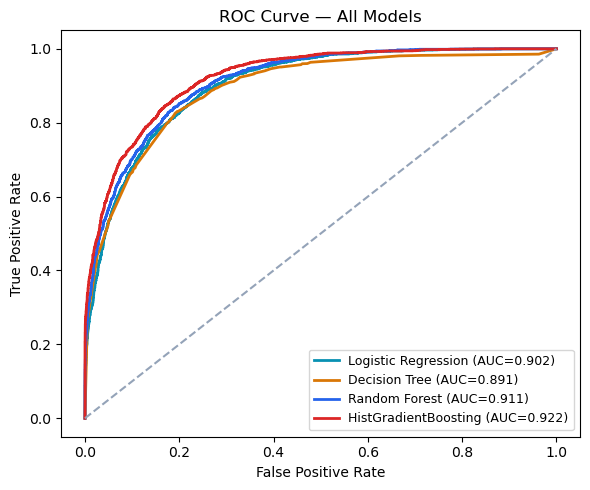

In [17]:
fig, ax = plt.subplots(figsize=(6, 5))
for name in MODELS:
    fpr, tpr, _ = roc_curve(y_test, y_proba_by_model[name])
    auc = performance_df.loc[name, 'roc_auc']
    ax.plot(fpr, tpr, color=MODEL_COLORS[name], linewidth=2, label=f'{name} (AUC={auc:.3f})')
ax.plot([0, 1], [0, 1], linestyle='--', color='#94a3b8')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — All Models')
ax.legend(loc='lower right', fontsize=9)
fig.tight_layout()
roc_img = fig_to_base64(fig)
plt.show()


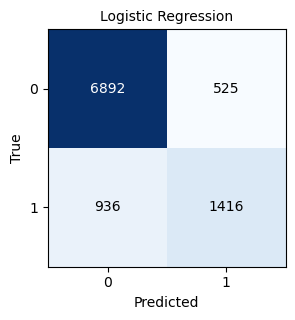

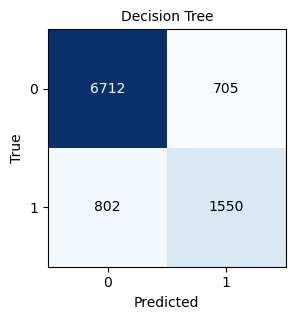

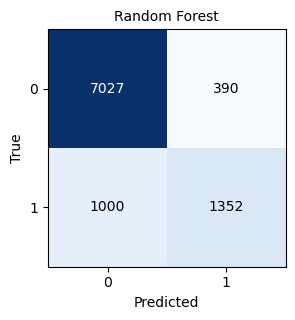

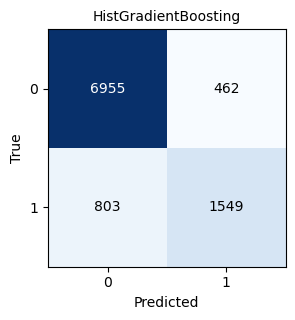

In [18]:
confusion_imgs = {}
for name in MODELS:
    cm = confusion_matrix(y_test, y_pred_by_model[name])
    fig, ax = plt.subplots(figsize=(3.6, 3.3))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(name, fontsize=10)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', color=color, fontsize=10)
    fig.tight_layout()
    confusion_imgs[name] = fig_to_base64(fig)
    plt.show()


## 4. SHAP / Feature Importance

Uses `TreeExplainer` for the three tree-based models (fast and exact) and
`LinearExplainer` for Logistic Regression (also fast and exact for linear models).
`shap.Explainer(...)` would auto-select these, but being explicit keeps the choice
visible and avoids silent fallback to the slow, approximate `KernelExplainer`.

In [19]:
shap_background = X_train.sample(min(200, len(X_train)), random_state=42)
shap_explain_set = X_test.sample(min(300, len(X_test)), random_state=42)

def compute_shap_values(name, model):
    if name == 'Logistic Regression':
        explainer = shap.LinearExplainer(model, shap_background)
    else:
        explainer = shap.TreeExplainer(model)
    sv = explainer.shap_values(shap_explain_set)
    # Normalize output shape across SHAP versions/model types to the positive-class array
    if isinstance(sv, list):
        sv = sv[1] if len(sv) > 1 else sv[0]
    elif hasattr(sv, 'ndim') and sv.ndim == 3:
        sv = sv[:, :, 1]
    return np.asarray(sv)

shap_values_by_model = {}
top_features_by_model = {}

for name, model in trained_models.items():
    sv = compute_shap_values(name, model)
    shap_values_by_model[name] = sv
    mean_abs = np.abs(sv).mean(axis=0)
    top_features_by_model[name] = sorted(
        zip(shap_explain_set.columns, mean_abs), key=lambda t: -t[1]
    )[:10]
    print(f'{name}: top feature = {top_features_by_model[name][0][0]}')


Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.


Logistic Regression: top feature = sex_Female
Decision Tree: top feature = marital.status_Married-civ-spouse
Random Forest: top feature = marital.status_Married-civ-spouse
HistGradientBoosting: top feature = marital.status_Married-civ-spouse


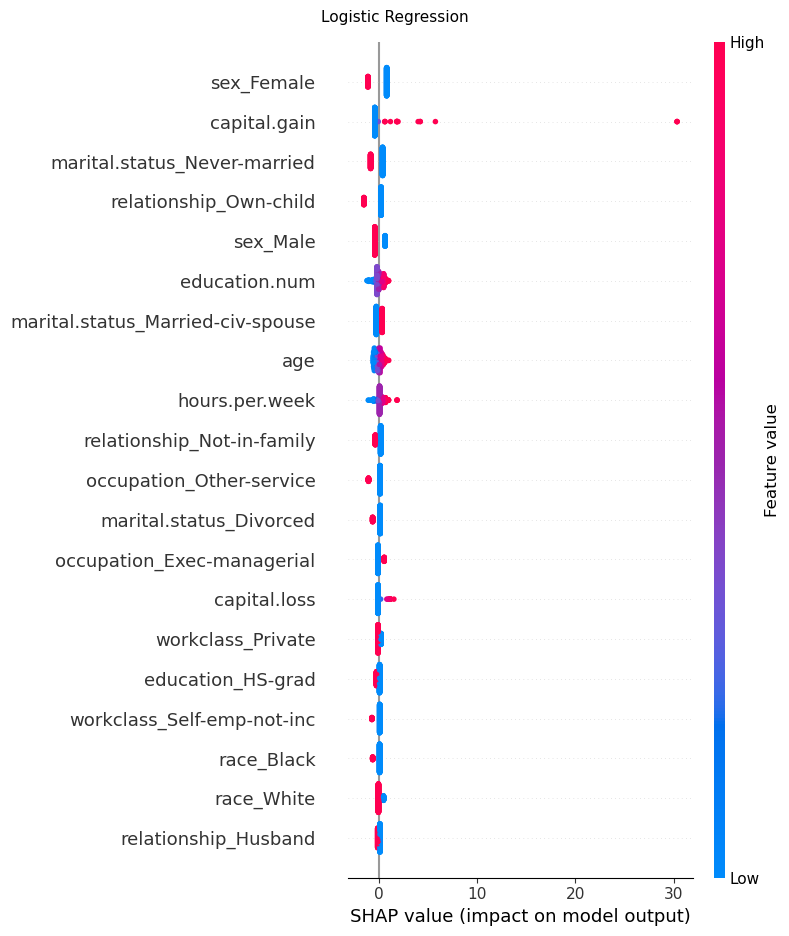

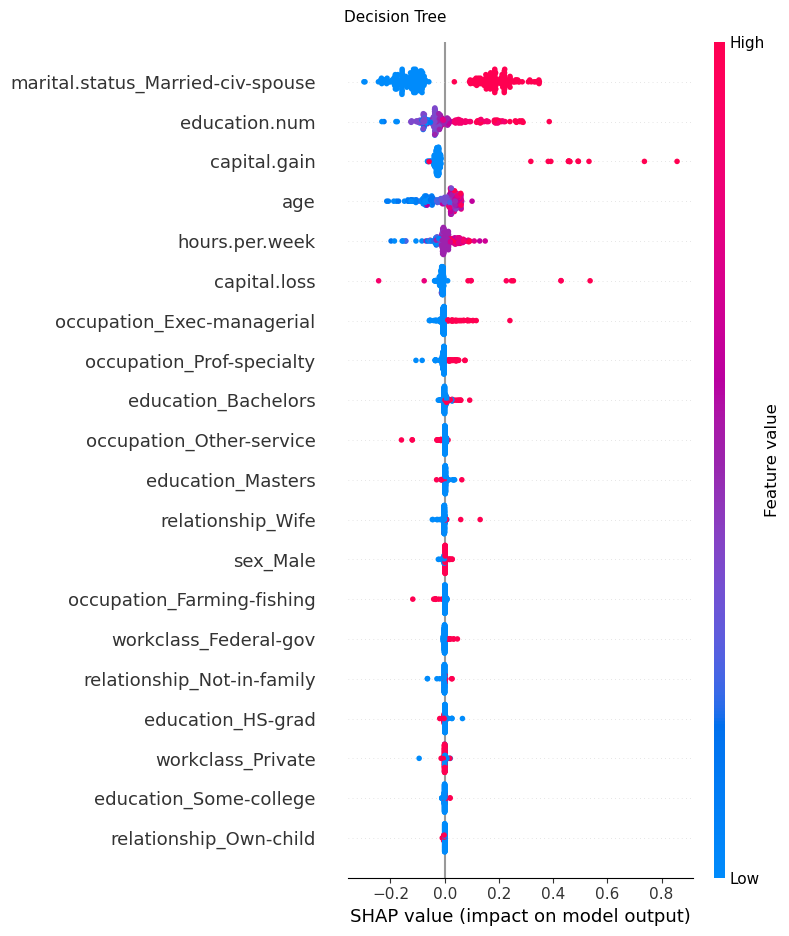

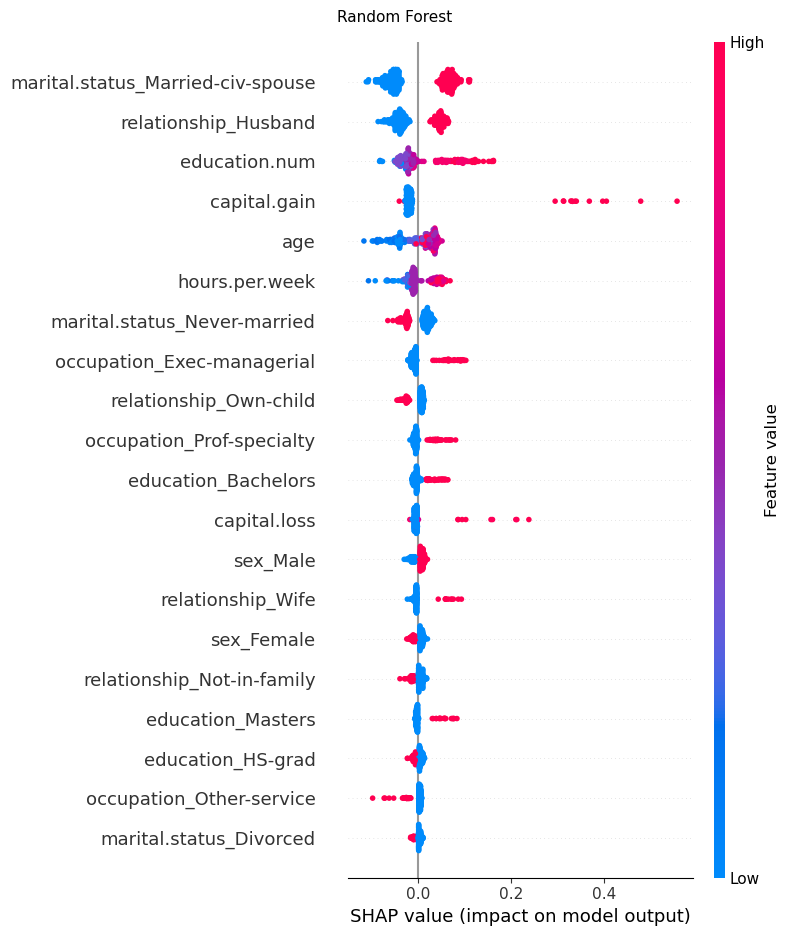

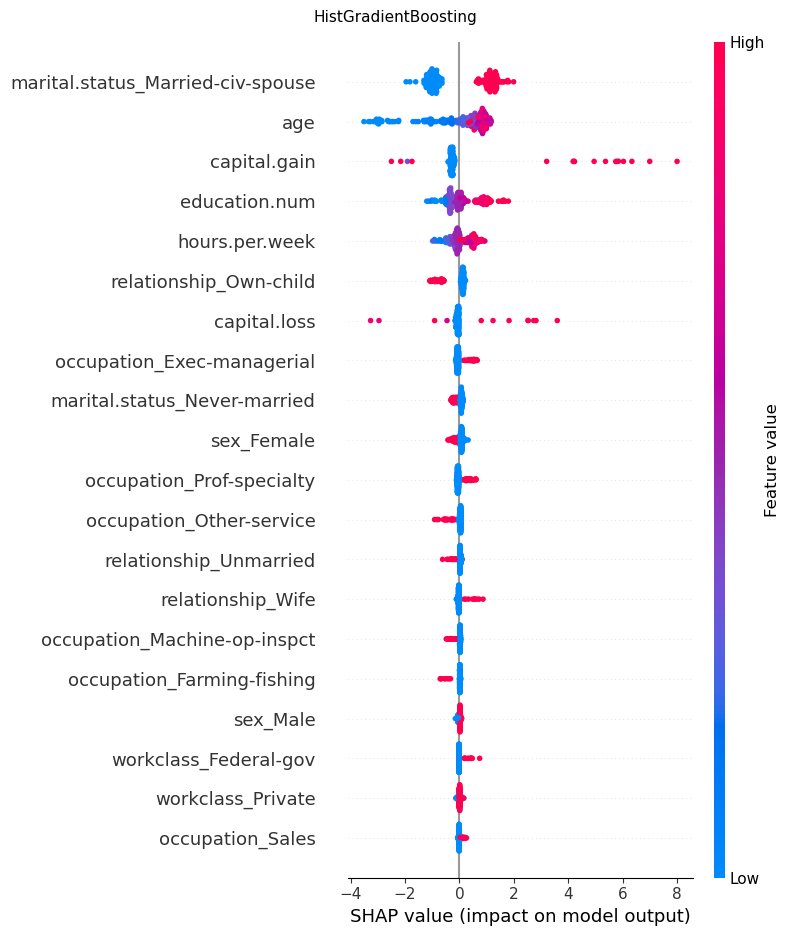

In [20]:
summary_imgs = {}
for name, sv in shap_values_by_model.items():
    fig = plt.figure(figsize=(6.5, 4.5))
    shap.summary_plot(sv, shap_explain_set, show=False)
    fig = plt.gcf()
    fig.suptitle(name, fontsize=11)
    fig.tight_layout()
    summary_imgs[name] = fig_to_base64(fig)
    plt.show()


In [21]:
# Explainability concentration heuristic: what share of total mean-|SHAP| sits in
# the top 3 features. Higher = a small handful of features tell the whole story,
# which is easier to summarize and audit than importance spread thin across many.
explainability_rows = []
for name, top in top_features_by_model.items():
    vals = np.array([v for _, v in top])
    concentration = float(vals[:3].sum() / vals.sum()) if vals.sum() > 0 else np.nan
    explainability_rows.append({
        'model': name,
        'top1_feature': top[0][0],
        'top3_concentration': concentration,
        'inherently_interpretable': INTERPRETABLE_BY_DESIGN[name],
    })
explainability_df = pd.DataFrame(explainability_rows).set_index('model')
explainability_df


,top1_feature,top3_concentration,inherently_interpretable
model,,,
Logistic Regression,sex_Female,0.487438,True
Decision Tree,marital.status_Married-civ-spouse,0.689298,True
Random Forest,marital.status_Married-civ-spouse,0.488672,False
HistGradientBoosting,marital.status_Married-civ-spouse,0.628353,False


## 5. Fairness Metrics

Same group-fairness metrics as before, computed for every model, **plus** a
with-vs-without-protected-attribute comparison: each model is retrained with the
`sex` one-hot columns removed to check whether disparity actually drops, or
whether it persists because other features (e.g. `relationship`,
`marital.status`) act as proxies for it.

In [22]:
fairness_rows = []
for name in MODELS:
    yp = y_pred_by_model[name]
    mf = MetricFrame(
        metrics={'accuracy': accuracy_score, 'selection_rate': selection_rate,
                 'false_positive_rate': false_positive_rate,
                 'false_negative_rate': false_negative_rate},
        y_true=y_test, y_pred=yp, sensitive_features=sex_test,
    )
    dpd = demographic_parity_difference(y_test, yp, sensitive_features=sex_test)
    eod = equalized_odds_difference(y_test, yp, sensitive_features=sex_test)
    sel = mf.by_group['selection_rate']
    disparate_impact = sel.min() / sel.max() if sel.max() > 0 else np.nan
    fairness_rows.append({
        'model': name,
        'selection_rate_female': sel.get('Female', np.nan),
        'selection_rate_male': sel.get('Male', np.nan),
        'demographic_parity_diff': dpd,
        'equalized_odds_diff': eod,
        'disparate_impact_ratio': disparate_impact,
    })

fairness_df = pd.DataFrame(fairness_rows).set_index('model')
fairness_df.round(4)


,selection_rate_female,selection_rate_male,demographic_parity_diff,equalized_odds_diff,disparate_impact_ratio
model,,,,,
Logistic Regression,0.0812,0.2564,0.1752,0.0897,0.3166
Decision Tree,0.0889,0.3005,0.2115,0.1060,0.2960
Random Forest,0.0712,0.2309,0.1597,0.0812,0.3084
HistGradientBoosting,0.0892,0.2631,0.1738,0.0600,0.3392


In [23]:
# --- With vs. without the protected attribute ---
protected_cols = [c for c in X.columns if c.startswith('sex_')]
X_train_np = X_train.drop(columns=protected_cols)
X_test_np = X_test.drop(columns=protected_cols)

fairness_noprotected_rows = []
for name, model_template in MODELS.items():
    model_np = type(model_template)(**model_template.get_params())
    model_np.fit(X_train_np, y_train)
    yp_np = model_np.predict(X_test_np)

    mf_np = MetricFrame(metrics={'selection_rate': selection_rate},
                         y_true=y_test, y_pred=yp_np, sensitive_features=sex_test)
    dpd_np = demographic_parity_difference(y_test, yp_np, sensitive_features=sex_test)
    eod_np = equalized_odds_difference(y_test, yp_np, sensitive_features=sex_test)
    sel_np = mf_np.by_group['selection_rate']
    di_np = sel_np.min() / sel_np.max() if sel_np.max() > 0 else np.nan

    fairness_noprotected_rows.append({
        'model': name,
        'accuracy_no_sex': accuracy_score(y_test, yp_np),
        'demographic_parity_diff_no_sex': dpd_np,
        'equalized_odds_diff_no_sex': eod_np,
        'disparate_impact_ratio_no_sex': di_np,
    })

fairness_noprotected_df = pd.DataFrame(fairness_noprotected_rows).set_index('model')

fairness_comparison_df = fairness_df[['demographic_parity_diff', 'disparate_impact_ratio']].join(
    fairness_noprotected_df[['demographic_parity_diff_no_sex', 'disparate_impact_ratio_no_sex']]
)
fairness_comparison_df['dpd_change'] = (
    fairness_comparison_df['demographic_parity_diff_no_sex'] - fairness_comparison_df['demographic_parity_diff']
)
fairness_comparison_df.round(4)


,demographic_parity_diff,disparate_impact_ratio,demographic_parity_diff_no_sex,disparate_impact_ratio_no_sex,dpd_change
model,,,,,
Logistic Regression,0.1752,0.3166,0.1709,0.3278,-0.0043
Decision Tree,0.2115,0.2960,0.2112,0.2992,-0.0003
Random Forest,0.1597,0.3084,0.1583,0.3046,-0.0013
HistGradientBoosting,0.1738,0.3392,0.1706,0.3535,-0.0033


If `demographic_parity_diff_no_sex` is close to `demographic_parity_diff`
(i.e. `dpd_change` is near zero), removing `sex` didn't help — the model is
recovering the same signal from correlated features like `relationship` or
`marital.status`. That's a real and reportable finding, not a bug in the
mitigation.

## 6. Robustness — Gaussian Noise + Feature Dropout

Two independent stress tests, run for every model:

1. **Gaussian noise** (as before) — perturbs numeric features by increasing
   fractions of their standard deviation.
2. **Feature dropout** (new) — randomly blanks out a fraction of *all* feature
   values per row (numeric and one-hot categorical alike), replacing each with
   its training-set median, to simulate missing or corrupted inputs at
   collection time.

In [25]:
noise_levels = (0.0, 0.05, 0.10, 0.20, 0.35)
numeric_columns = [c for c in X_test.columns
                    if pd.api.types.is_numeric_dtype(X_test[c]) and X_test[c].nunique() > 2]
stds = X_test[numeric_columns].std()

def apply_gaussian_noise(X_df, level, rng):
    if level == 0:
        return X_df
    X_noisy = X_df.copy()
    for col in numeric_columns:
        scale = level * (stds[col] if stds[col] > 0 else 1.0)
        X_noisy[col] = X_noisy[col] + rng.normal(loc=0.0, scale=scale, size=len(X_noisy))
    return X_noisy

noise_results = []
for name, model in trained_models.items():
    rng = np.random.RandomState(42)
    for level in noise_levels:
        X_noisy = apply_gaussian_noise(X_test, level, rng)
        yp_noisy = model.predict(X_noisy)
        noise_results.append({
            'model': name, 'noise_level': level,
            'accuracy': accuracy_score(y_test, yp_noisy),
            'f1_score': f1_score(y_test, yp_noisy, zero_division=0),
        })

noise_df = pd.DataFrame(noise_results)
noise_df.pivot(index='noise_level', columns='model', values='accuracy').round(4)


model,Decision Tree,HistGradientBoosting,Logistic Regression,Random Forest
noise_level,,,,
0.00,0.8457,0.8705,0.8504,0.8577
0.05,0.8427,0.8413,0.8509,0.8560
0.10,0.8391,0.8330,0.8497,0.8547
0.20,0.8286,0.8301,0.8458,0.8532
0.35,0.8226,0.8226,0.8311,0.8434


In [26]:
dropout_rates = (0.0, 0.05, 0.10, 0.20, 0.35)
train_medians = X_train.median()

def apply_feature_dropout(X_df, rate, rng):
    if rate == 0:
        return X_df
    mask = rng.rand(*X_df.shape) < rate
    arr = X_df.values.astype(float)
    fill = train_medians.values
    rows, colidx = np.where(mask)
    arr[rows, colidx] = fill[colidx]
    return pd.DataFrame(arr, columns=X_df.columns, index=X_df.index)

dropout_results = []
for name, model in trained_models.items():
    rng = np.random.RandomState(42)
    for rate in dropout_rates:
        X_dropped = apply_feature_dropout(X_test, rate, rng)
        yp_dropped = model.predict(X_dropped)
        dropout_results.append({
            'model': name, 'dropout_rate': rate,
            'accuracy': accuracy_score(y_test, yp_dropped),
            'f1_score': f1_score(y_test, yp_dropped, zero_division=0),
        })

dropout_df = pd.DataFrame(dropout_results)
dropout_df.pivot(index='dropout_rate', columns='model', values='accuracy').round(4)


model,Decision Tree,HistGradientBoosting,Logistic Regression,Random Forest
dropout_rate,,,,
0.00,0.8457,0.8705,0.8504,0.8577
0.05,0.8389,0.8640,0.8451,0.8549
0.10,0.8298,0.8563,0.8417,0.8473
0.20,0.8232,0.8467,0.8335,0.8374
0.35,0.8009,0.8283,0.8149,0.8207


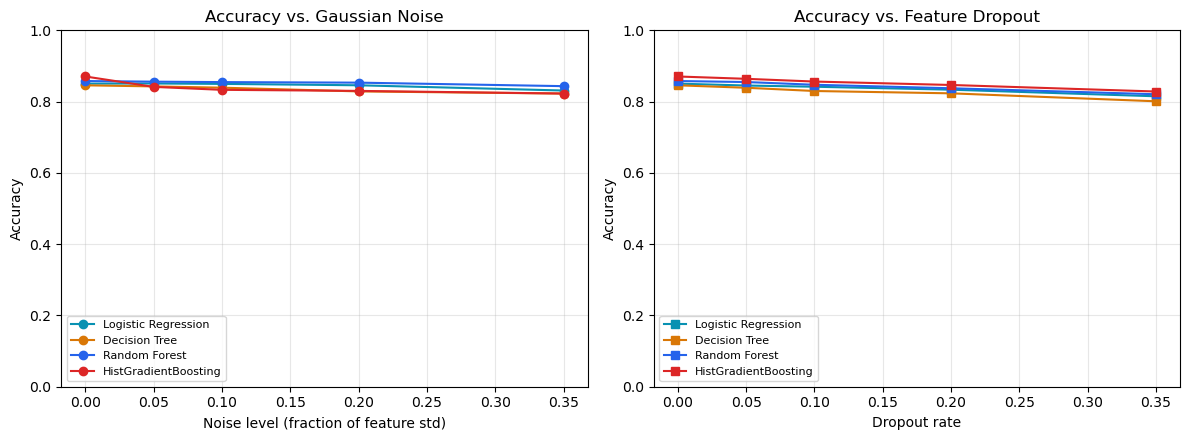

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name in MODELS:
    sub = noise_df[noise_df['model'] == name]
    axes[0].plot(sub['noise_level'], sub['accuracy'], marker='o', color=MODEL_COLORS[name], label=name)
    sub2 = dropout_df[dropout_df['model'] == name]
    axes[1].plot(sub2['dropout_rate'], sub2['accuracy'], marker='s', color=MODEL_COLORS[name], label=name)

axes[0].set_title('Accuracy vs. Gaussian Noise')
axes[0].set_xlabel('Noise level (fraction of feature std)')
axes[1].set_title('Accuracy vs. Feature Dropout')
axes[1].set_xlabel('Dropout rate')
for ax in axes:
    ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1); ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.tight_layout()
robustness_img = fig_to_base64(fig)
plt.show()


In [28]:
# Summary robustness score per model: mean accuracy drop from baseline (noise_level/dropout_rate = 0),
# averaged across BOTH stress tests and all non-zero severities. Lower = more robust.
def mean_drop(df, level_col):
    out = {}
    for name in MODELS:
        sub = df[df['model'] == name].sort_values(level_col)
        baseline = sub.iloc[0]['accuracy']
        drops = baseline - sub[sub[level_col] > 0]['accuracy']
        out[name] = drops.mean()
    return out

noise_drop = mean_drop(noise_df, 'noise_level')
dropout_drop = mean_drop(dropout_df, 'dropout_rate')

robustness_summary_df = pd.DataFrame({
    'mean_accuracy_drop_noise': noise_drop,
    'mean_accuracy_drop_dropout': dropout_drop,
})
robustness_summary_df['mean_accuracy_drop_overall'] = robustness_summary_df.mean(axis=1)
robustness_summary_df.round(4)


,mean_accuracy_drop_noise,mean_accuracy_drop_dropout,mean_accuracy_drop_overall
Logistic Regression,0.0061,0.0166,0.0113
Decision Tree,0.0125,0.0225,0.0175
Random Forest,0.0059,0.0176,0.0118
HistGradientBoosting,0.0387,0.0217,0.0302


## 7. Final Trust Report

Five headline findings, each computed from a specific, visible rule rather than
asserted — the rule is printed alongside the answer so it can be checked or
re-weighted.

In [29]:
def minmax_norm(s, higher_is_better=True):
    s = s.astype(float)
    if s.max() == s.min():
        return pd.Series(1.0, index=s.index)
    norm = (s - s.min()) / (s.max() - s.min())
    return norm if higher_is_better else 1 - norm

# --- individual rankings ---
best_performance_model = performance_df['roc_auc'].idxmax()

# most explainable: inherently-interpretable models rank above post-hoc-only ones;
# ties within each group broken by SHAP concentration (fewer features needed to explain it)
explain_rank_df = explainability_df.copy()
explain_rank_df['rank_key'] = (
    explain_rank_df['inherently_interpretable'].astype(int) * 10 + explain_rank_df['top3_concentration']
)
most_explainable_model = explain_rank_df['rank_key'].idxmax()

highest_fairness_risk_model = fairness_df['demographic_parity_diff'].idxmax()
most_robust_model = robustness_summary_df['mean_accuracy_drop_overall'].idxmin()

# --- composite "safest model" score ---
perf_score = performance_df[['accuracy', 'f1_score', 'roc_auc']].apply(minmax_norm).mean(axis=1)
fair_score = pd.concat([
    minmax_norm(fairness_df['demographic_parity_diff'], higher_is_better=False),
    minmax_norm(fairness_df['equalized_odds_diff'], higher_is_better=False),
    minmax_norm(fairness_df['disparate_impact_ratio'], higher_is_better=True),
], axis=1).mean(axis=1)
robust_score = minmax_norm(robustness_summary_df['mean_accuracy_drop_overall'], higher_is_better=False)
explain_score = minmax_norm(explain_rank_df['rank_key'], higher_is_better=True)

WEIGHTS = {'performance': 0.35, 'fairness': 0.30, 'robustness': 0.25, 'explainability': 0.10}

composite_df = pd.DataFrame({
    'performance_score': perf_score,
    'fairness_score': fair_score,
    'robustness_score': robust_score,
    'explainability_score': explain_score,
})
composite_df['safety_score'] = (
    WEIGHTS['performance'] * composite_df['performance_score']
    + WEIGHTS['fairness'] * composite_df['fairness_score']
    + WEIGHTS['robustness'] * composite_df['robustness_score']
    + WEIGHTS['explainability'] * composite_df['explainability_score']
)
safest_model = composite_df['safety_score'].idxmax()

print('Weights used:', WEIGHTS, '\n')
print('Best performing model (highest ROC-AUC):      ', best_performance_model)
print('Most explainable model:                       ', most_explainable_model)
print('Model with highest fairness risk (max DPD):   ', highest_fairness_risk_model)
print('Most robust model (smallest avg accuracy drop):', most_robust_model)
print('Safest model to use (highest composite score): ', safest_model)
print()
composite_df.round(4).sort_values('safety_score', ascending=False)


Weights used: {'performance': 0.35, 'fairness': 0.3, 'robustness': 0.25, 'explainability': 0.1} 

Best performing model (highest ROC-AUC):       HistGradientBoosting
Most explainable model:                        Decision Tree
Model with highest fairness risk (max DPD):    Decision Tree
Most robust model (smallest avg accuracy drop): Logistic Regression
Safest model to use (highest composite score):  HistGradientBoosting



,performance_score,fairness_score,robustness_score,explainability_score,safety_score
HistGradientBoosting,1.0000,0.9090,0.0000,0.0137,0.6241
Logistic Regression,0.1763,0.5106,1.0000,0.9802,0.5629
Random Forest,0.3765,0.6090,0.9783,0.0000,0.5591
Decision Tree,0.0874,0.0000,0.6732,1.0000,0.2989


**Reading the composite score:** it's a weighted average, not a hidden
verdict — `WEIGHTS` above is the one place to change if performance, fairness,
robustness, or explainability matters more for your use case than the default
35/30/25/10 split. A high-performance model with a large fairness gap can still
lose to a slightly-less-accurate model that treats groups more equally, and
that trade-off is visible in the table rather than buried in a single number.

## 8. Generate HTML Report

Assembles everything above — per-model performance, SHAP, fairness, robustness,
and the final trust summary — into a single self-contained HTML file
(`evaluation_report.html`), with charts embedded as base64 images.

In [30]:
REPORT_TEMPLATE = Template(r'''
<!DOCTYPE html><html lang="en"><head><meta charset="UTF-8">
<title>{{ report_title }}</title>
<style>
  :root { --ink:#1e293b; --muted:#64748b; --line:#e2e8f0; --bg-card:#f8fafc;
          --good:#16a34a; --warn:#d97706; --bad:#dc2626; }
  * { box-sizing: border-box; }
  body { font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, sans-serif;
         color: var(--ink); max-width: 1080px; margin: 0 auto; padding: 40px 24px 80px; line-height: 1.5; }
  .section{ background:#fff; border:1px solid #e5e7eb; border-radius:14px; padding:24px;
            margin:32px 0; box-shadow:0 3px 12px rgba(0,0,0,.05); }
  h1 { font-size: 28px; margin-bottom: 4px; }
  .subtitle { color: var(--muted); font-size: 14px; margin-bottom: 36px; }
  h2 { font-size: 20px; border-bottom: 2px solid var(--line); padding-bottom: 8px; margin-top: 48px; }
  h3 { font-size: 16px; margin-top: 24px; }
  .metric-grid { display: grid; grid-template-columns: repeat(auto-fit, minmax(140px, 1fr)); gap: 12px; margin: 20px 0; }
  .metric-card { background: white; border-left: 5px solid #2563eb; border-radius: 12px; padding: 14px 16px;
                 box-shadow: 0 2px 8px rgba(0,0,0,.05); }
  .metric-card .label { font-size: 12px; color: var(--muted); text-transform: uppercase; letter-spacing: .03em; }
  .metric-card .value { font-size: 22px; font-weight: 600; margin-top: 4px; }
  .img-row { display: flex; gap: 20px; flex-wrap: wrap; margin: 20px 0; justify-content: center; }
  .img-row img { max-width: 460px; width: 100%; border: 1px solid var(--line); border-radius: 8px; }
  table { border-collapse: collapse; width: 100%; overflow: hidden; border-radius: 12px; margin: 16px 0; font-size: 14px; }
  thead { background: #1e40af; color: white; }
  th, td { padding: 8px 12px; text-align: left; }
  tbody tr:nth-child(even) { background: #f8fafc; }
  tbody tr:hover { background: #eff6ff; }
  .note { background:#eff6ff; border-left:5px solid #2563eb; padding:15px; border-radius:10px; color:#334155; margin-top:15px; }
  .explanation { background:#f8fafc; border:1px solid #e2e8f0; padding:18px; border-radius:10px; margin:20px 0; }
  .explanation ul { margin:8px 0 0 20px; }
  .explanation li { margin-bottom:8px; }
  .badge { display:inline-block; padding:4px 10px; border-radius:999px; font-size:12px; font-weight:600; color:white; margin:2px 4px 2px 0; }
  .badge.best { background:var(--good); }
  .badge.risk { background:var(--bad); }
  .badge.robust { background:#0891b2; }
  .badge.explain { background:#7c3aed; }
  .badge.safe { background:#1d4ed8; }
  .model-block { border:1px solid var(--line); border-radius:10px; padding:16px; margin-bottom:18px; }
  .model-block h4 { margin:0 0 10px; font-size:15px; }
  footer { margin-top: 60px; color: var(--muted); font-size: 12px; text-align: center; }
  .hero { background: linear-gradient(135deg,#1d4ed8,#2563eb); color:white; padding:35px; border-radius:16px; margin-bottom:35px; }
  .hero h1 { margin:0; color:white; }
  .hero p { margin:10px 0 20px; opacity:.95; }
  .hero-info { display:flex; gap:25px; flex-wrap:wrap; font-size:14px; }
  details { margin: 12px 0; }
  summary { cursor: pointer; font-weight: 600; padding: 6px 0; }
</style></head><body>

<div class="hero">
  <h1>{{ report_title }}</h1>
  <p>Comparative evaluation of {{ model_names|length }} classifiers on predictive performance,
     explainability, fairness, and robustness.</p>
  <div class="hero-info">
    <span><b>Generated:</b> {{ generated_at }}</span>
    <span><b>Models:</b> {{ model_names|join(', ') }}</span>
    <span><b>Test samples:</b> {{ test_set_size }}</span>
  </div>
</div>

<div class="section">
  <h2>Trust Summary</h2>
  <p class="section-desc">Each label below follows directly from the tables in this report — see
     the "Final Trust Report" section of the notebook for the exact rule behind each one.</p>
  <p>
    <span class="badge best">Best performing: {{ best_performance_model }}</span>
    <span class="badge explain">Most explainable: {{ most_explainable_model }}</span>
    <span class="badge risk">Highest fairness risk: {{ highest_fairness_risk_model }}</span>
    <span class="badge robust">Most robust: {{ most_robust_model }}</span>
    <span class="badge safe">Safest overall: {{ safest_model }}</span>
  </p>
  <table>
    <tr><th>Model</th><th>Perf. score</th><th>Fairness score</th><th>Robustness score</th><th>Explainability score</th><th><b>Safety score</b></th></tr>
    {% for row in composite_rows %}
    <tr><td>{{ row.model }}</td><td>{{ "%.3f"|format(row.performance_score) }}</td>
        <td>{{ "%.3f"|format(row.fairness_score) }}</td><td>{{ "%.3f"|format(row.robustness_score) }}</td>
        <td>{{ "%.3f"|format(row.explainability_score) }}</td><td><b>{{ "%.3f"|format(row.safety_score) }}</b></td></tr>
    {% endfor %}
  </table>
  <div class="note">Safety score = {{ weights.performance }}×performance + {{ weights.fairness }}×fairness
    + {{ weights.robustness }}×robustness + {{ weights.explainability }}×explainability (each 0–1, higher is better).
    Adjust the weights in the notebook if a different priority order fits your use case.</div>
</div>

<div class="section">
  <h2>1. Model Performance</h2>
  <table>
    <tr><th>Model</th><th>Accuracy</th><th>Precision</th><th>Recall</th><th>F1</th><th>ROC-AUC</th></tr>
    {% for row in performance_rows %}
    <tr><td>{{ row.model }}</td><td>{{ "%.3f"|format(row.accuracy) }}</td><td>{{ "%.3f"|format(row.precision) }}</td>
        <td>{{ "%.3f"|format(row.recall) }}</td><td>{{ "%.3f"|format(row.f1_score) }}</td><td>{{ "%.3f"|format(row.roc_auc) }}</td></tr>
    {% endfor %}
  </table>
  <div class="img-row"><img src="data:image/png;base64,{{ roc_img }}"></div>
  <h3>Confusion matrices</h3>
  <div class="img-row">
    {% for name, img in confusion_imgs.items() %}<img src="data:image/png;base64,{{ img }}">{% endfor %}
  </div>
</div>

<div class="section">
  <h2>2. SHAP / Feature Importance</h2>
  <table>
    <tr><th>Model</th><th>Top feature</th><th>Top-3 concentration</th><th>Inherently interpretable</th></tr>
    {% for row in explainability_rows %}
    <tr><td>{{ row.model }}</td><td>{{ row.top1_feature }}</td><td>{{ "%.3f"|format(row.top3_concentration) }}</td>
        <td>{{ 'Yes' if row.inherently_interpretable else 'No (post-hoc only)' }}</td></tr>
    {% endfor %}
  </table>
  {% for name, img in summary_imgs.items() %}
  <details><summary>{{ name }} — SHAP summary plot</summary>
    <div class="img-row"><img src="data:image/png;base64,{{ img }}"></div>
  </details>
  {% endfor %}
  <div class="note">"Top-3 concentration" is the share of total mean-|SHAP| held by the 3 most
    important features — higher means a small handful of features tell most of the story.
    "Inherently interpretable" is about the model's structure (can you read off the whole decision rule?),
    which is a stronger form of transparency than a post-hoc SHAP explanation on a black-box ensemble.</div>
</div>

<div class="section">
  <h2>3. Fairness Metrics</h2>
  <p class="section-desc">Group fairness across the <code>sex</code> attribute. Disparate impact ratio
    below 0.8 is flagged by the "four-fifths rule", a common legal/regulatory adverse-impact threshold.</p>
  <table>
    <tr><th>Model</th><th>Sel. rate (F)</th><th>Sel. rate (M)</th><th>Demographic parity diff</th><th>Equalized odds diff</th><th>Disparate impact ratio</th></tr>
    {% for row in fairness_rows %}
    <tr><td>{{ row.model }}</td><td>{{ "%.3f"|format(row.selection_rate_female) }}</td><td>{{ "%.3f"|format(row.selection_rate_male) }}</td>
        <td>{{ "%.3f"|format(row.demographic_parity_diff) }}</td><td>{{ "%.3f"|format(row.equalized_odds_diff) }}</td>
        <td {% if row.disparate_impact_ratio < 0.8 %}style="color:var(--bad);font-weight:600"{% endif %}>{{ "%.3f"|format(row.disparate_impact_ratio) }}</td></tr>
    {% endfor %}
  </table>
  <h3>With vs. without the protected attribute</h3>
  <table>
    <tr><th>Model</th><th>DPD (with sex)</th><th>DPD (without sex)</th><th>Change</th><th>Disparate impact (without sex)</th></tr>
    {% for row in fairness_comparison_rows %}
    <tr><td>{{ row.model }}</td><td>{{ "%.3f"|format(row.demographic_parity_diff) }}</td>
        <td>{{ "%.3f"|format(row.demographic_parity_diff_no_sex) }}</td>
        <td>{{ "%+.3f"|format(row.dpd_change) }}</td>
        <td>{{ "%.3f"|format(row.disparate_impact_ratio_no_sex) }}</td></tr>
    {% endfor %}
  </table>
  <div class="note">A near-zero change after removing <code>sex</code> means the model recovered the
    same signal from correlated ("proxy") features — dropping the protected attribute did not, by itself,
    fix the disparity. That's a legitimate finding about the data, not a pipeline bug.</div>
</div>

<div class="section">
  <h2>4. Robustness</h2>
  <p class="section-desc">Two stress tests per model: Gaussian noise on numeric features, and
    feature dropout (random blanking, replaced by the training median) across all features.</p>
  <div class="img-row"><img src="data:image/png;base64,{{ robustness_img }}"></div>
  <table>
    <tr><th>Model</th><th>Mean accuracy drop — noise</th><th>Mean accuracy drop — dropout</th><th>Mean accuracy drop — overall</th></tr>
    {% for row in robustness_rows %}
    <tr><td>{{ row.model }}</td><td>{{ "%.3f"|format(row.mean_accuracy_drop_noise) }}</td>
        <td>{{ "%.3f"|format(row.mean_accuracy_drop_dropout) }}</td><td><b>{{ "%.3f"|format(row.mean_accuracy_drop_overall) }}</b></td></tr>
    {% endfor %}
  </table>
</div>

<footer>Generated by the multi-model trust evaluation pipeline · {{ generated_at }}</footer>
</body></html>
''')


In [31]:
composite_rows = composite_df.reset_index().rename(columns={'index': 'model'}).to_dict('records')
performance_rows_r = performance_df.reset_index().to_dict('records')
explainability_rows_r = explainability_df.reset_index().to_dict('records')
fairness_rows_r = fairness_df.reset_index().to_dict('records')
fairness_comparison_rows_r = fairness_comparison_df.reset_index().to_dict('records')
robustness_rows_r = robustness_summary_df.reset_index().to_dict('records')

html_out = REPORT_TEMPLATE.render(
    report_title='Multi-Model Trust Evaluation — Adult Census Income',
    generated_at=datetime.now().strftime('%Y-%m-%d %H:%M'),
    model_names=list(MODELS),
    test_set_size=len(X_test),
    best_performance_model=best_performance_model,
    most_explainable_model=most_explainable_model,
    highest_fairness_risk_model=highest_fairness_risk_model,
    most_robust_model=most_robust_model,
    safest_model=safest_model,
    weights=WEIGHTS,
    composite_rows=composite_rows,
    performance_rows=performance_rows_r,
    roc_img=roc_img,
    confusion_imgs=confusion_imgs,
    explainability_rows=explainability_rows_r,
    summary_imgs=summary_imgs,
    fairness_rows=fairness_rows_r,
    fairness_comparison_rows=fairness_comparison_rows_r,
    robustness_img=robustness_img,
    robustness_rows=robustness_rows_r,
)

with open('evaluation_report.html', 'w', encoding='utf-8') as f:
    f.write(html_out)

print('Report written to evaluation_report.html')
display(HTML('<a href="evaluation_report.html" target="_blank">Open evaluation_report.html</a>'))


Report written to evaluation_report.html
